# Geospatial Data Analysis

## Objective

The objective of this project is to analyze location-based sales data to identify regions with high business potential. The analysis focuses on sales performance across different cities, states, and regions to identify areas suitable for business expansion and improve decision-making.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

## Step 1: Load the Dataset

The Superstore dataset is loaded into a Pandas DataFrame. Displaying the first few records helps verify that the dataset has been imported successfully.

In [3]:
import pandas as pd

df = pd.read_csv("/content/sample_data/Sample - Superstore.csv", encoding="latin1")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Step 2: Explore the Dataset

This step examines the dimensions, column names, and data types to understand the structure of the dataset before analysis.

In [4]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

Dataset Shape: (9994, 21)

Column Names:
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   

## Step 3: Check Missing Values

Missing values are identified to ensure that the dataset is complete and suitable for analysis.

In [5]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


## Step 4: Check Duplicate Records

Duplicate records can affect the reliability of the analysis. This step identifies duplicate rows in the dataset.

In [6]:
duplicates = df.duplicated().sum()

print("Duplicate Records:", duplicates)

Duplicate Records: 0


## Step 5: Remove Duplicate Records

Duplicate rows are removed to improve data quality and ensure accurate analysis.

In [7]:
df = df.drop_duplicates()

print("Dataset Shape After Removing Duplicates:", df.shape)

Dataset Shape After Removing Duplicates: (9994, 21)


## Step 6: Analyze Sales by Region

This step calculates the total sales generated in each region to identify the best-performing business locations.

In [8]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

print(region_sales)

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64


## Step 7: Visualize Regional Sales

A bar chart is created to compare total sales across different regions.

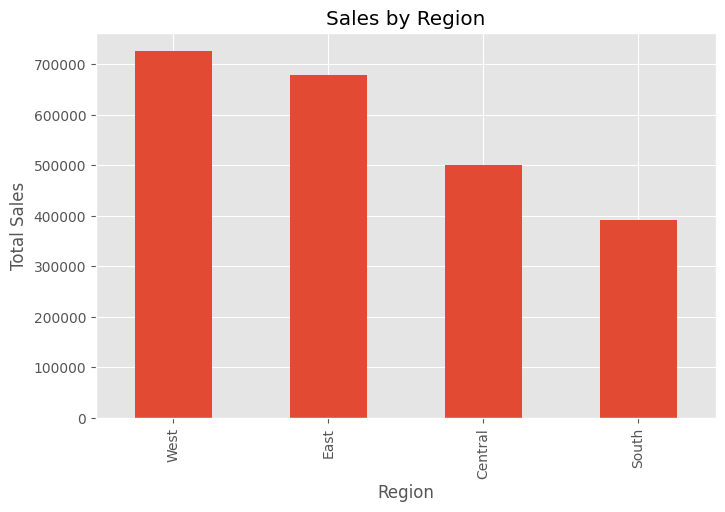

In [9]:
region_sales.plot(kind="bar", figsize=(8,5))

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.show()

## Step 8: Analyze Sales by State

This analysis identifies the states with the highest total sales, helping locate strong markets.

In [10]:
top_states = df.groupby("State")["Sales"].sum().sort_values(ascending=False).head(10)

print(top_states)

State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Florida          89473.7080
Illinois         80166.1010
Ohio             78258.1360
Michigan         76269.6140
Virginia         70636.7200
Name: Sales, dtype: float64


## Step 9: Visualize Top States

A bar chart displays the top ten states based on total sales.

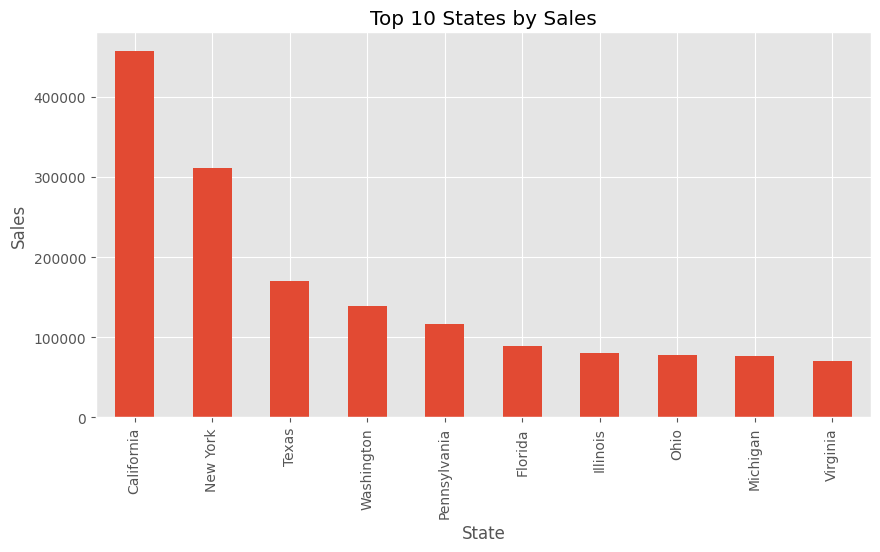

In [11]:
top_states.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 States by Sales")
plt.xlabel("State")
plt.ylabel("Sales")

plt.show()

## Step 10: Analyze Sales by City

This step identifies the cities generating the highest sales and highlights areas with strong customer demand.

In [12]:
top_cities = df.groupby("City")["Sales"].sum().sort_values(ascending=False).head(10)

print(top_cities)

City
New York City    256368.1610
Los Angeles      175851.3410
Seattle          119540.7420
San Francisco    112669.0920
Philadelphia     109077.0130
Houston           64504.7604
Chicago           48539.5410
San Diego         47521.0290
Jacksonville      44713.1830
Springfield       43054.3420
Name: Sales, dtype: float64


## Step 11: Identify Business Expansion Opportunities

Regions with high sales and positive profits are considered potential locations for future business expansion.

In [13]:
expansion = df.groupby(["Region","State"])[["Sales","Profit"]].sum().sort_values("Sales", ascending=False)

print(expansion.head(10))

                            Sales      Profit
Region  State                                
West    California    457687.6315  76381.3871
East    New York      310876.2710  74038.5486
Central Texas         170188.0458 -25729.3563
West    Washington    138641.2700  33402.6517
East    Pennsylvania  116511.9140 -15559.9603
South   Florida        89473.7080  -3399.3017
Central Illinois       80166.1010 -12607.8870
East    Ohio           78258.1360 -16971.3766
Central Michigan       76269.6140  24463.1876
South   Virginia       70636.7200  18597.9504


## Step 12: Correlation Analysis

Correlation analysis measures the relationship between sales, quantity, discount, and profit.

In [14]:
numeric = df[["Sales","Quantity","Discount","Profit"]]

numeric.corr()

,Sales,Quantity,Discount,Profit
Sales,1.000000,0.200795,-0.028190,0.479064
Quantity,0.200795,1.000000,0.008623,0.066253
Discount,-0.028190,0.008623,1.000000,-0.219487
Profit,0.479064,0.066253,-0.219487,1.000000


## Step 13: Save the Processed Dataset

After completing the analysis, the processed dataset is exported as a new CSV file.

In [15]:
df.to_csv("cleaned_superstore_sales.csv", index=False)

print("Processed dataset exported successfully.")

Processed dataset exported successfully.
